In [ ]:
from pathlib import Path
from scipy.io import loadmat
import sys
import os

# Use the actual notebook working directory
nb_dir = Path.cwd()
print(f"Current notebook path: {nb_dir}")

# Optionally add the notebook dir (for local-only imports)
if str(nb_dir) not in sys.path:
    sys.path.insert(0, str(nb_dir))
    print(f"Added {nb_dir} to sys.path")

repo_root = nb_dir.parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    print(f"Added {repo_root} to sys.path")

In [2]:
import torch
import matplotlib.pyplot as plt
from utils import trainer
from utils import utils
from Systems import DynamicSystem
import Filters
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = device  # For backward compatibility
print(f"device: {device}")

device: cuda


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import Systems


# Parametry sekvencí
TRAIN_SEQ_LEN = 100       # Délka sekvence pro trénink (např. 100 kroků = 100 sekund při 1Hz)
VAL_SEQ_LEN = 300
TEST_SEQ_LEN = 1000      # Délka sekvence pro testování (delší sekvence pro stabilnější vyhodnocení)
STRIDE = 15         # Posun okna (překryv) pro data augmentation
BATCH_SIZE = 256
DATA_PATH = 'data/processed'
print(f"Běží na zařízení: {device}")

Běží na zařízení: cuda


In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import os

def prepare_sequences(dataset_list, seq_len, stride, mode='train'):
    """
    Zpracuje list trajektorií na sekvence pro trénink dle článku.
    
    Nový formát dle [Song et al., 2024]:
    - Vstup u (4D): [v_left, v_right, theta_imu, omega_imu]
    - Cíl x (6D):   [px, py, vx, vy, theta, omega]
    """
    X_seq_list = [] # Ground Truth (Cíl)
    Y_seq_list = [] # GPS Měření (Vstup do korekce)
    U_seq_list = [] # Control Input (IMU/Odo)
    
    print(f"Zpracovávám {len(dataset_list)} trajektorií pro {mode}...")
    
    for traj in dataset_list:
        # 1. Extrahuje data
        # GT z preprocessingu je [px, py, theta]
        gt = traj['ground_truth'].float() 
        
        # GPS: [x, y] (obsahuje NaN!)
        gps = traj['filtered_gps'].float()
        
        # IMU: [ax, ay, theta, omega]
        imu = traj['imu'].float()
        theta_imu = imu[:, 2] # Orientace z IMU
        omega_imu = imu[:, 3] # Úhlová rychlost z IMU
        
        # ODO: [v_left, v_right]
        odo = traj['filtered_wheel'].float()
        
        # Fix NaN v odometrii (nahradíme nulou)
        v_left = torch.nan_to_num(odo[:, 0], nan=0.0)
        v_right = torch.nan_to_num(odo[:, 1], nan=0.0)
        
        # 2. Sestavení vstupu u = [v_l, v_r, theta_imu, omega_imu] (4D)
        # Toto odpovídá "State Model" definovanému v článku (sekce II.C.2)
        u = torch.stack((v_left, v_right, theta_imu, omega_imu), dim=1)
        
        # 3. Sestavení cíle x (6D) pro state vector [px, py, vx, vy, theta, omega]
        # Vyplníme to, co máme z Ground Truth (px, py, theta).
        # Rychlosti (vx, vy, omega) v GT implicitně nemáme (nebo je složité je derivovat přesně),
        # ale pro trénink Loss funkce budeme stejně porovnávat primárně pozici.
        T = gt.shape[0]
        x_target = torch.zeros(T, 6)
        x_target[:, 0] = gt[:, 0] # px
        x_target[:, 1] = gt[:, 1] # py
        x_target[:, 4] = gt[:, 2] # theta
        # Ostatní (vx, vy, omega) zůstávají 0, protože v Loss funkci budeme maskovat nebo brát jen pozici.
        
        # 4. Sliding Window (Rozsekání na sekvence)
        num_samples = gt.shape[0]
        current_stride = stride if mode == 'train' else seq_len # U testu bez překryvu
        
        for i in range(0, num_samples - seq_len + 1, current_stride):
            # Cíl: 6D stav
            x_seq = x_target[i : i+seq_len, :]
            
            # Měření: GPS [px, py]
            y_seq = gps[i : i+seq_len, :]
            
            # Vstup: 4D control input
            u_seq = u[i : i+seq_len, :]
            
            X_seq_list.append(x_seq)
            Y_seq_list.append(y_seq)
            U_seq_list.append(u_seq)
            
    # Stack do tenzorů
    X_out = torch.stack(X_seq_list)
    Y_out = torch.stack(Y_seq_list)
    U_out = torch.stack(U_seq_list)
    
    return X_out, Y_out, U_out

# === NAČTENÍ DAT ===
# Ujistíme se, že cesty a konstanty jsou definované (pokud nejsou, doplňte je nahoře)
# if 'DATA_PATH' not in locals(): DATA_PATH = 'data/processed'
# if 'TRAIN_SEQ_LEN' not in locals(): TRAIN_SEQ_LEN = 100
# if 'VAL_SEQ_LEN' not in locals(): VAL_SEQ_LEN = 200
# if 'TEST_SEQ_LEN' not in locals(): TEST_SEQ_LEN = 500
# if 'STRIDE' not in locals(): STRIDE = 20
# if 'BATCH_SIZE' not in locals(): BATCH_SIZE = 256
DATA_PATH = os.path.join('..', 'data', 'processed')
print(f"Hledám data v: {os.path.abspath(DATA_PATH)}")
try:
    train_data_raw = torch.load(os.path.join(DATA_PATH, 'train.pt'))
    val_data_raw = torch.load(os.path.join(DATA_PATH, 'val.pt'))
    test_data_raw = torch.load(os.path.join(DATA_PATH, 'test.pt'))
    print("Data úspěšně načtena!")
except FileNotFoundError as e:
    print(f"Chyba: {e}")
    print(f"Program se dívá do složky: {os.getcwd()}")
# Načtení celého balíku
# train_data_full = torch.load(os.path.join(DATA_PATH, 'train.pt'))

# === RYCHLÝ TEST: OŘÍZNUTÍ DAT ===
# Vezmeme jen prvních 5 trajektorií z 22. 
# To radikálně zrychlí jednu epochu a umožní rychle otestovat stabilitu hyperparametrů.
# train_data_raw = train_data_full[:10] 

print(f"DEBUG: Pro rychlý test používám jen {len(train_data_raw)} trajektorií.")
# ... zbytek kódu beze změny

# === PŘÍPRAVA SEKVENCÍ ===
print("--- Generuji trénovací data (Paper compatible) ---")
train_X, train_Y, train_U = prepare_sequences(train_data_raw, TRAIN_SEQ_LEN, STRIDE, 'train')

print("\n--- Generuji validační data ---")
val_X, val_Y, val_U = prepare_sequences(val_data_raw, VAL_SEQ_LEN, VAL_SEQ_LEN, 'val')

print("\n--- Generuji testovací data ---")
test_X, test_Y, test_U = prepare_sequences(test_data_raw, TEST_SEQ_LEN, TEST_SEQ_LEN, 'test')

# Vytvoření DataLoaderů
train_loader = DataLoader(TensorDataset(train_X, train_Y, train_U), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_X, val_Y, val_U), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(test_X, test_Y, test_U), batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ Data připravena.")
print(f"Train batches: {len(train_loader)}")
print(f"Shapes -> X: {train_X.shape} (6D State), U: {train_U.shape} (4D Input), Y: {train_Y.shape} (2D Meas)")

Hledám data v: /home/luky/skola/KalmanNet-main/navigation NCLT dataset/data/processed
Data úspěšně načtena!
DEBUG: Pro rychlý test používám jen 22 trajektorií.
--- Generuji trénovací data (Paper compatible) ---
Zpracovávám 22 trajektorií pro train...

--- Generuji validační data ---
Zpracovávám 2 trajektorií pro val...

--- Generuji testovací data ---
Zpracovávám 3 trajektorií pro test...

✅ Data připravena.
Train batches: 29
Shapes -> X: torch.Size([7259, 100, 6]) (6D State), U: torch.Size([7259, 100, 4]) (4D Input), Y: torch.Size([7259, 100, 2]) (2D Meas)


In [5]:
# === INICIALIZACE DYNAMICKÉHO MODELU (System Instance - Paper Version) ===

# 1. Parametry systému podle článku [Song et al., 2024]
# State (6D): [px, py, vx, vy, theta, omega]
# Referenční rovnice (5) v článku.
state_dim = 6
# Meas (2D):  [gps_x, gps_y]
# Referenční rovnice (6) v článku.
obs_dim = 2
# Časový krok (z preprocessingu)
dt = 1.0  

# 2. Definice Matice Q (Procesní šum / Model Uncertainty)
# Nyní máme 6 stavů. Musíme definovat nejistotu pro každý z nich.
# Hodnoty jsou nastaveny heuristicky (lze ladit):
# - Pozice (idx 0,1): 0.1
# - Rychlost (idx 2,3): 0.1
# - Úhel/Omega (idx 4,5): 0.01 (IMU je v NCLT docela přesné, ale driftuje)
q_diag = torch.tensor([0.1, 0.1, 0.1, 0.1, 0.01, 0.01])
Q = torch.diag(q_diag)

# 3. Definice Matice R (Šum měření / Sensor Noise)
# GPS měří jen pozici (px, py).
# Nastavujeme 1.0 m^2. To odpovídá standardní odchylce 1m.
# Pokud je GPS v datasetu horší, KalmanNet se naučí "nedůvěřovat" vstupu y
# a spoléhat více na predikci z u (odometrie).
r_diag = torch.tensor([1.0, 1.0])
R = torch.diag(r_diag)

# 4. Počáteční podmínky (Prior)
# Ex0: Nulový vektor 6x1
Ex0 = torch.zeros(state_dim, 1)

# P0: Počáteční kovariance
# Autoři používají P k inicializaci EKF[cite: 700].
# Nastavíme rozumnou počáteční nejistotu.
P0 = torch.eye(state_dim) * 0.5

# 5. Vytvoření instance DynamicSystemNCLT
# Důležité: f=None zajistí, že se použije interní `_f_paper_dynamics` (rovnice 5),
# která očekává 4D vstup (v_l, v_r, theta, omega).
sys_model = Systems.DynamicSystemNCLT(
    state_dim=state_dim,
    obs_dim=obs_dim,
    Q=Q,
    R=R,
    Ex0=Ex0,
    P0=P0,
    dt=dt,
    f=None,  # None -> Použije se model z článku: px += vc*cos(theta_imu)...
    h=None,  # None -> Použije se GPS model: y = [px, py]
    device=DEVICE
)

print(f"✅ System Model NCLT inicializován (Paper Version).")
print(f" - State Dim: {sys_model.state_dim} [px, py, vx, vy, theta, omega]")
print(f" - Meas Dim:  {sys_model.obs_dim} [gps_x, gps_y]")
print(f" - Input Dim: 4 [v_l, v_r, theta_imu, omega_imu]") # Implicitně v modelu
print(f" - Q Diag: {q_diag.tolist()}")

✅ System Model NCLT inicializován (Paper Version).
 - State Dim: 6 [px, py, vx, vy, theta, omega]
 - Meas Dim:  2 [gps_x, gps_y]
 - Input Dim: 4 [v_l, v_r, theta_imu, omega_imu]
 - Q Diag: [0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.009999999776482582, 0.009999999776482582]


In [6]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# from copy import deepcopy

# def train_RKN(
#     model, 
#     train_loader, 
#     val_loader, 
#     device, 
#     epochs=100, 
#     lr=1e-3, 
#     clip_grad=1.0, 
#     early_stopping_patience=20, 
#     optimizer_type=torch.optim.AdamW,
#     weight_decay=1e-5,
#     use_nll_loss=False
# ):
#     if use_nll_loss and not model.returns_covariance:
#         raise ValueError("Cannot use NLL Loss if model.returns_covariance is False.")

#     optimizer = optimizer_type(model.parameters(), lr=lr, weight_decay=weight_decay)
#     scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

#     best_val_loss = float('inf')
#     best_val_mse_at_opt = float('inf')
#     optimal_epoch = 0
#     epochs_no_improve = 0
#     best_model_state = None

#     print(f"🚀 START RKN Training (Epochs: {epochs}, LR: {lr}, NLL Loss: {use_nll_loss})")

#     for epoch in range(epochs):
#         model.train()
#         train_loss_sum = 0.0
#         train_mse_metric_sum = 0.0

#         for batch_data in train_loader:
#             # === ROZBALENÍ DAT (PODPORA PRO u_input) ===
#             if len(batch_data) == 3:
#                 x_true_batch, y_meas_batch, u_input_batch = batch_data
#                 has_u = True
#             else:
#                 x_true_batch, y_meas_batch = batch_data
#                 has_u = False

#             x_true_batch = x_true_batch.to(device)
#             y_meas_batch = y_meas_batch.to(device)
#             if has_u:
#                 u_input_batch = u_input_batch.to(device)

#             batch_size, seq_len, _ = x_true_batch.shape

#             optimizer.zero_grad()
#             model.reset(batch_size=batch_size, initial_state=x_true_batch[:, 0, :])

#             predictions_x = []
#             predictions_P = []

#             for t in range(1, seq_len):
#                 y_t = y_meas_batch[:, t, :]
#                 u_t = u_input_batch[:, t, :] if has_u else None  # Získání u_t
                
#                 # === VOLÁNÍ KROKU S u_t ===
#                 if model.returns_covariance:
#                     x_filtered_t, P_filtered_t, _ = model.step(y_t, u_t)
#                     predictions_P.append(P_filtered_t)
#                 else:
#                     x_filtered_t, _ = model.step(y_t, u_t)
#                 predictions_x.append(x_filtered_t)

#             predicted_trajectory = torch.stack(predictions_x, dim=1)
#             target_trajectory = x_true_batch[:, 1:, :]

#             if use_nll_loss:
#                 predicted_cov_trajectory = torch.stack(predictions_P, dim=1)
#                 I_eps = torch.eye(model.state_dim, device=device).view(1, 1, model.state_dim, model.state_dim) * 1e-6
#                 safe_cov = predicted_cov_trajectory + I_eps
                
#                 error = (target_trajectory - predicted_trajectory).unsqueeze(-1)
#                 flat_cov = safe_cov.view(-1, model.state_dim, model.state_dim)
#                 flat_err = error.view(-1, model.state_dim, 1)
                
#                 try:
#                     cov_inv = torch.linalg.pinv(flat_cov, hermitian=True)
#                     mahalanobis = torch.bmm(torch.bmm(flat_err.transpose(1, 2), cov_inv), flat_err).squeeze()
#                     sign, logdet = torch.linalg.slogdet(flat_cov)
#                     loss = 0.5 * (mahalanobis + logdet).mean()
#                 except torch._C._LinAlgError:
#                     loss = F.mse_loss(predicted_trajectory, target_trajectory)
#             else:
#                 loss = F.mse_loss(predicted_trajectory, target_trajectory)

#             loss.backward()
#             if clip_grad > 0:
#                 nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
#             optimizer.step()
            
#             train_loss_sum += loss.item()
#             with torch.no_grad():
#                 train_mse_metric_sum += F.mse_loss(predicted_trajectory, target_trajectory).item()

#         scheduler.step()
#         avg_train_loss = train_loss_sum / len(train_loader)
#         avg_train_mse = train_mse_metric_sum / len(train_loader)

#         # === Validation Phase ===
#         model.eval()
#         val_loss_sum = 0.0
#         val_mse_sum = 0.0
#         val_anees_sum = 0.0 
        
#         with torch.no_grad():
#             for val_batch_data in val_loader:
#                 # === ROZBALENÍ DAT (PODPORA PRO u_input) ===
#                 if len(val_batch_data) == 3:
#                     x_true_val, y_meas_val, u_input_val = val_batch_data
#                     has_u_val = True
#                 else:
#                     x_true_val, y_meas_val = val_batch_data
#                     has_u_val = False

#                 x_true_val = x_true_val.to(device)
#                 y_meas_val = y_meas_val.to(device)
#                 if has_u_val:
#                     u_input_val = u_input_val.to(device)

#                 batch_size_val, seq_len_val, _ = x_true_val.shape

#                 model.reset(batch_size=batch_size_val, initial_state=x_true_val[:, 0, :])
                
#                 val_predictions_x = []
#                 val_predictions_P = []

#                 for t in range(1, seq_len_val):
#                     y_t_val = y_meas_val[:, t, :]
#                     u_t_val = u_input_val[:, t, :] if has_u_val else None # Získání u_t_val

#                     # === VOLÁNÍ KROKU S u_t_val ===
#                     if model.returns_covariance:
#                         x_filtered_t_val, P_filtered_t_val, _ = model.step(y_t_val, u_t_val)
#                         val_predictions_P.append(P_filtered_t_val)
#                     else:
#                         x_filtered_t_val, _ = model.step(y_t_val, u_t_val)
#                     val_predictions_x.append(x_filtered_t_val)
                    
#                 predicted_val_trajectory = torch.stack(val_predictions_x, dim=1)
#                 target_val_trajectory = x_true_val[:, 1:, :]

#                 if use_nll_loss:
#                     predicted_cov_val = torch.stack(val_predictions_P, dim=1)
#                     safe_cov_val = predicted_cov_val + I_eps
#                     error_val = (target_val_trajectory - predicted_val_trajectory).unsqueeze(-1)
#                     flat_cov_v = safe_cov_val.view(-1, model.state_dim, model.state_dim)
#                     flat_err_v = error_val.view(-1, model.state_dim, 1)
                    
#                     try:
#                         cov_inv_v = torch.linalg.pinv(flat_cov_v, hermitian=True)
#                         mahal_v = torch.bmm(torch.bmm(flat_err_v.transpose(1, 2), cov_inv_v), flat_err_v).squeeze()
#                         _, logdet_v = torch.linalg.slogdet(flat_cov_v)
#                         loss_v = 0.5 * (mahal_v + logdet_v).mean()
                        
#                         val_anees_sum += mahal_v.mean().item()  
#                     except torch._C._LinAlgError:
#                         loss_v = F.mse_loss(predicted_val_trajectory, target_val_trajectory)
#                         val_anees_sum += float('nan')
#                 else:
#                     loss_v = F.mse_loss(predicted_val_trajectory, target_val_trajectory)
                
#                 val_loss_sum += loss_v.item()
#                 val_mse_sum += F.mse_loss(predicted_val_trajectory, target_val_trajectory).item()

#         avg_val_loss = val_loss_sum / len(val_loader)
#         avg_val_mse = val_mse_sum / len(val_loader)
#         avg_val_anees = val_anees_sum / len(val_loader) if use_nll_loss else float('nan')
        
#         if use_nll_loss:
#             print(f"Epoch: {epoch+1}/{epochs} | Train NLL: {avg_train_loss:.4f} | Val NLL: {avg_val_loss:.4f} | MSE: {avg_val_mse:.4f} | ANEES: {avg_val_anees:.2f} | LR: {scheduler.get_last_lr()[0]:.2e}")
#         else:
#             print(f"Epoch: {epoch+1}/{epochs} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")
        
#         if avg_val_loss < best_val_loss:
#             best_val_loss = avg_val_loss
#             best_val_mse_at_opt = avg_val_mse
#             optimal_epoch = epoch + 1
#             epochs_no_improve = 0
#             best_model_state = deepcopy(model.state_dict())
#             print(f"  >>> Optimal idx: {optimal_epoch} | Optimal Val Loss: {best_val_loss:.4f} <<<")
#         else:
#             epochs_no_improve += 1

#         if epochs_no_improve >= early_stopping_patience:
#             print(f"\nEarly stopping triggered after {epoch + 1} epochs.")
#             break
            
#     print("\nTraining complete. Best Validation Loss:", best_val_loss)
#     if best_model_state:
#         model.load_state_dict(best_model_state)
#         print("Optimal model loaded.")
        
#     return {
#         "final_model": model,
#         "best_epoch": optimal_epoch,
#         "best_val_loss": best_val_loss,
#         "best_val_mse": best_val_mse_at_opt
#     }

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from copy import deepcopy

def train_RKN(
    model, 
    train_loader, 
    val_loader, 
    device, 
    epochs=100, 
    lr=1e-3, 
    clip_grad=1.0, 
    early_stopping_patience=20, 
    optimizer_type=torch.optim.AdamW,
    weight_decay=1e-5,
    use_nll_loss=False,
    lambda_mse=10.0 # <--- NOVÝ PARAMETR (KOTVA PRO MSE)
):
    if use_nll_loss and not model.returns_covariance:
        raise ValueError("Cannot use NLL Loss if model.returns_covariance is False.")

    optimizer = optimizer_type(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

    best_val_loss = float('inf')
    best_val_mse_at_opt = float('inf')
    optimal_epoch = 0
    epochs_no_improve = 0
    best_model_state = None

    print(f"🚀 START RKN Training (Epochs: {epochs}, LR: {lr}, NLL Loss: {use_nll_loss}, Lambda MSE: {lambda_mse})")

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        train_mse_metric_sum = 0.0

        for batch_data in train_loader:
            if len(batch_data) == 3:
                x_true_batch, y_meas_batch, u_input_batch = batch_data
                has_u = True
            else:
                x_true_batch, y_meas_batch = batch_data
                has_u = False

            x_true_batch = x_true_batch.to(device)
            y_meas_batch = y_meas_batch.to(device)
            if has_u: u_input_batch = u_input_batch.to(device)

            batch_size, seq_len, _ = x_true_batch.shape

            optimizer.zero_grad()
            model.reset(batch_size=batch_size, initial_state=x_true_batch[:, 0, :])

            predictions_x = []
            predictions_P = []

            for t in range(1, seq_len):
                y_t = y_meas_batch[:, t, :]
                u_t = u_input_batch[:, t, :] if has_u else None
                
                if model.returns_covariance:
                    x_filtered_t, P_filtered_t, _ = model.step(y_t, u_t)
                    predictions_P.append(P_filtered_t)
                else:
                    x_filtered_t, _ = model.step(y_t, u_t)
                predictions_x.append(x_filtered_t)

            predicted_trajectory = torch.stack(predictions_x, dim=1)
            target_trajectory = x_true_batch[:, 1:, :]

            if use_nll_loss:
                predicted_cov_trajectory = torch.stack(predictions_P, dim=1)
                I_eps = torch.eye(model.state_dim, device=device).view(1, 1, model.state_dim, model.state_dim) * 1e-6
                safe_cov = predicted_cov_trajectory + I_eps
                
                error = (target_trajectory - predicted_trajectory).unsqueeze(-1)
                flat_cov = safe_cov.view(-1, model.state_dim, model.state_dim)
                flat_err = error.view(-1, model.state_dim, 1)
                
                try:
                    cov_inv = torch.linalg.pinv(flat_cov, hermitian=True)
                    mahalanobis = torch.bmm(torch.bmm(flat_err.transpose(1, 2), cov_inv), flat_err).squeeze()
                    _, logdet = torch.linalg.slogdet(flat_cov)
                    
                    nll_loss = 0.5 * (mahalanobis + logdet).mean()
                    mse_loss = F.mse_loss(predicted_trajectory, target_trajectory)
                    
                    # === KLÍČOVÁ ZMĚNA: HYBRIDNÍ LOSS ===
                    loss = nll_loss + (lambda_mse * mse_loss)
                except torch._C._LinAlgError:
                    loss = F.mse_loss(predicted_trajectory, target_trajectory)
            else:
                loss = F.mse_loss(predicted_trajectory, target_trajectory)

            loss.backward()
            if clip_grad > 0:
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            
            train_loss_sum += loss.item()
            with torch.no_grad():
                train_mse_metric_sum += F.mse_loss(predicted_trajectory, target_trajectory).item()

        scheduler.step()
        avg_train_loss = train_loss_sum / len(train_loader)
        avg_train_mse = train_mse_metric_sum / len(train_loader)

        # === Validation Phase ===
        model.eval()
        val_loss_sum = 0.0
        val_mse_sum = 0.0
        val_anees_sum = 0.0 
        
        with torch.no_grad():
            for val_batch_data in val_loader:
                if len(val_batch_data) == 3:
                    x_true_val, y_meas_val, u_input_val = val_batch_data
                    has_u_val = True
                else:
                    x_true_val, y_meas_val = val_batch_data
                    has_u_val = False

                x_true_val = x_true_val.to(device)
                y_meas_val = y_meas_val.to(device)
                if has_u_val: u_input_val = u_input_val.to(device)

                batch_size_val, seq_len_val, _ = x_true_val.shape
                model.reset(batch_size=batch_size_val, initial_state=x_true_val[:, 0, :])
                
                val_predictions_x = []
                val_predictions_P = []

                for t in range(1, seq_len_val):
                    y_t_val = y_meas_val[:, t, :]
                    u_t_val = u_input_val[:, t, :] if has_u_val else None

                    if model.returns_covariance:
                        x_filtered_t_val, P_filtered_t_val, _ = model.step(y_t_val, u_t_val)
                        val_predictions_P.append(P_filtered_t_val)
                    else:
                        x_filtered_t_val, _ = model.step(y_t_val, u_t_val)
                    val_predictions_x.append(x_filtered_t_val)
                    
                predicted_val_trajectory = torch.stack(val_predictions_x, dim=1)
                target_val_trajectory = x_true_val[:, 1:, :]

                if use_nll_loss:
                    predicted_cov_val = torch.stack(val_predictions_P, dim=1)
                    safe_cov_val = predicted_cov_val + I_eps
                    error_val = (target_val_trajectory - predicted_val_trajectory).unsqueeze(-1)
                    flat_cov_v = safe_cov_val.view(-1, model.state_dim, model.state_dim)
                    flat_err_v = error_val.view(-1, model.state_dim, 1)
                    
                    try:
                        cov_inv_v = torch.linalg.pinv(flat_cov_v, hermitian=True)
                        mahal_v = torch.bmm(torch.bmm(flat_err_v.transpose(1, 2), cov_inv_v), flat_err_v).squeeze()
                        _, logdet_v = torch.linalg.slogdet(flat_cov_v)
                        
                        nll_loss_v = 0.5 * (mahal_v + logdet_v).mean()
                        mse_loss_v = F.mse_loss(predicted_val_trajectory, target_val_trajectory)
                        
                        # Zde používáme stejnou kombinaci pro konzistentní výběr best modelu
                        loss_v = nll_loss_v + (lambda_mse * mse_loss_v) 
                        val_anees_sum += mahal_v.mean().item()  
                    except torch._C._LinAlgError:
                        loss_v = F.mse_loss(predicted_val_trajectory, target_val_trajectory)
                        val_anees_sum += float('nan')
                else:
                    loss_v = F.mse_loss(predicted_val_trajectory, target_val_trajectory)
                
                val_loss_sum += loss_v.item()
                val_mse_sum += F.mse_loss(predicted_val_trajectory, target_val_trajectory).item()

        avg_val_loss = val_loss_sum / len(val_loader)
        avg_val_mse = val_mse_sum / len(val_loader)
        avg_val_anees = val_anees_sum / len(val_loader) if use_nll_loss else float('nan')
        
        if use_nll_loss:
            print(f"Epoch: {epoch+1}/{epochs} | T-Loss: {avg_train_loss:.2f} | V-Loss: {avg_val_loss:.2f} | MSE: {avg_val_mse:.4f} | ANEES: {avg_val_anees:.2f} | LR: {scheduler.get_last_lr()[0]:.1e}")
        else:
            print(f"Epoch: {epoch+1}/{epochs} | T-Loss(MSE): {avg_train_loss:.4f} | V-Loss(MSE): {avg_val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.1e}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_val_mse_at_opt = avg_val_mse
            optimal_epoch = epoch + 1
            epochs_no_improve = 0
            best_model_state = deepcopy(model.state_dict())
            print(f"  >>> Optimal idx: {optimal_epoch} | Optimal Val Loss: {best_val_loss:.4f} <<<")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stopping_patience:
            print(f"\nEarly stopping triggered after {epoch + 1} epochs.")
            break
            
    print("\nTraining complete.")
    if best_model_state:
        model.load_state_dict(best_model_state)
        print("Optimal model loaded.")
        
    return {
        "final_model": model,
        "best_epoch": optimal_epoch,
        "best_val_loss": best_val_loss,
        "best_val_mse": best_val_mse_at_opt,
        "best_val_anees": avg_val_anees if use_nll_loss else float('nan')
    }

In [ ]:
# import random
# import numpy as np
# import torch
# from torch.utils.data import TensorDataset, DataLoader
# from state_NN_models import StateRecursiveKalmanNet

# # Konfigurace sítě
# rkn_architecture_config = {
#     'nb_layer_FC1': 1, 'FC1_mult': 10,
#     'nbr_GRU': 1, 'hidden_size_mult': 10,
#     'nb_layer_FC2': 1, 'FC2_mult': 20,
# }

# model_config = {
#     "config": rkn_architecture_config,
#     "weight_factor": 0.1,         
#     "returns_covariance": True    
# }

# torch.manual_seed(42)
# np.random.seed(42)
# random.seed(42)

# print("="*80)
# print("INICIALIZACE MODELU RKN (Pro 4D Systém)")
# print("="*80)

# state_rkn = StateRecursiveKalmanNet(
#     sys_model,
#     device=device,
#     **model_config
# ).to(device)


# # ==============================================================================
# # FÁZE 1: STABILIZACE (Pouze MSE)
# # ==============================================================================
# print("\n" + "="*80)
# print("🚀 FÁZE 1: Trénink Polohy (MSE Loss)")
# print("="*80)

# train_config_phase1 = {
#     "epochs": 100,               
#     "lr": 1e-3,
#     "clip_grad": 1.0,           
#     "early_stopping_patience": 20,
#     "use_nll_loss": False,
#     "lambda_mse": 1.0           # Ve Fázi 1 nemá vliv
# }

# results_phase1 = train_RKN(
#     model=state_rkn,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
#     **train_config_phase1
# )

# # ==============================================================================
# # FÁZE 2: KALIBRACE NEJISTOTY (Hybrid Loss: NLL + silné MSE)
# # ==============================================================================
# print("\n" + "="*80)
# print("🚀 FÁZE 2: Trénink Kovariance (Hybrid Loss NLL + MSE) - Cílíme na ANEES ~4.0")
# print("="*80)

# train_config_phase2 = {
#     "epochs": 200,               
#     "lr": 5e-5,                 # <<< ZMĚNA: 5x Pomalější učení než minule (ochrana proti rozbití)
#     "clip_grad": 0.5,           # <<< ZMĚNA: Přísnější ořezání gradientů
#     "early_stopping_patience": 30,
#     "use_nll_loss": True,
#     "lambda_mse": 50.0          # <<< ZMĚNA: Kotva! Síť bude tvrdě trestána za zhoršení MSE
# }

# results_phase2 = train_RKN(
#     model=results_phase1['final_model'], 
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
#     **train_config_phase2
# )

# trained_model = results_phase2['final_model']

# # ==============================================================================
# # VÝSLEDKY
# # ==============================================================================
# print("\n" + "="*80)
# print("TRÉNINK DOKONČEN - FINÁLNÍ VÝSLEDKY Z NEJLEPŠÍHO MODELU")
# print("="*80)
# print(f"Nejlepší model byl nalezen v epoše (Fáze 2): {results_phase2['best_epoch']}")
# print("--- Metriky odpovídající tomuto nejlepšímu modelu ---")
# print(f"  MSE na validační sadě:       {results_phase2['best_val_mse']:.4f}")
# print(f"  Validační Loss (Hybrid):     {results_phase2['best_val_loss']:.4f}")
# print(f"  ANEES (průměrný):           {results_phase2['best_val_anees']:.2f}")
# print("="*80)

import random
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from state_NN_models import StateRecursiveKalmanNet

# Konfigurace sítě (Parametry jsou v pořádku, měnit je nemusíte)
rkn_architecture_config = {
    'nb_layer_FC1': 1, 'FC1_mult': 5,
    'nbr_GRU': 1, 'hidden_size_mult': 7,
    'nb_layer_FC2': 1, 'FC2_mult': 12,
}

model_config = {
    "config": rkn_architecture_config,
    "weight_factor": 0.1,         
    "returns_covariance": True    
}

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("="*80)
print("INICIALIZACE MODELU RKN (Pro 4D/6D Systém)")
print("="*80)

state_rkn = StateRecursiveKalmanNet(
    sys_model,
    device=device,
    **model_config
).to(device)


# ==============================================================================
# FÁZE 1: STABILIZACE POLOHY (Pouze MSE)
# ==============================================================================
print("\n" + "="*80)
print("🚀 FÁZE 1: Trénink Polohy (MSE Loss)")
print("="*80)

train_config_phase1 = {
    "epochs": 100,               # Stačí 50, pokud to minule končilo na 42
    "lr": 1e-3,
    "clip_grad": 1.0,           
    "early_stopping_patience": 30,
    "use_nll_loss": False,
    "lambda_mse": 1.0,
    "weight_decay": 1e-3            # Lehké L2 regularizace pro stabilitu           
}

results_phase1 = train_RKN(
    model=state_rkn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    **train_config_phase1
)

# ==============================================================================
# PŘÍPRAVA NA FÁZI 2: ZMRAZENÍ rnn_K
# Tímto krokem garantujeme, že MSE se už nikdy nezhorší!
# ==============================================================================
model_for_phase2 = results_phase1['final_model']

print("\n❄️ Zmrazuji váhy rnn_K (Kalman Gain) pro zachování MSE...")
for param in model_for_phase2.rnn_K.parameters():
    param.requires_grad = False

# ==============================================================================
# FÁZE 2: KALIBRACE NEJISTOTY (Pouze rnn_cov)
# ==============================================================================
print("\n" + "="*80)
print("🚀 FÁZE 2: Trénink Kovariance (NLL Loss) - Cílíme na ANEES")
print("="*80)

train_config_phase2 = {
    "epochs": 100,               
    "lr": 1e-4,                 # Můžeme se vrátit k vyššímu LR, rnn_K je v bezpečí
    "clip_grad": 1.0,           
    "early_stopping_patience": 30,
    "use_nll_loss": True,
    "lambda_mse": 0.0,
    "weight_decay": 1e-2
}

results_phase2 = train_RKN(
    model=model_for_phase2, 
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    **train_config_phase2
)

# ==============================================================================
# ODKLIZENÍ ZMRAZENÍ (pro případné další použití modelu)
# ==============================================================================
trained_model = results_phase2['final_model']
for param in trained_model.rnn_K.parameters():
    param.requires_grad = True

# ==============================================================================
# VÝSLEDKY
# ==============================================================================
print("\n" + "="*80)
print("TRÉNINK DOKONČEN - FINÁLNÍ VÝSLEDKY Z NEJLEPŠÍHO MODELU")
print("="*80)
print(f"Nejlepší model byl nalezen v epoše (Fáze 2): {results_phase2['best_epoch']}")
print("--- Metriky odpovídající tomuto nejlepšímu modelu ---")
print(f"  MSE na validační sadě:       {results_phase2['best_val_mse']:.4f}")
print(f"  Validační Loss (NLL):        {results_phase2['best_val_loss']:.4f}")
print(f"  ANEES (průměrný):           {results_phase2['best_val_anees']:.2f}")
print("="*80)

INICIALIZACE MODELU RKN (Pro 4D/6D Systém)

🚀 FÁZE 1: Trénink Polohy (MSE Loss)
🚀 START RKN Training (Epochs: 100, LR: 0.001, NLL Loss: False, Lambda MSE: 1.0)
Epoch: 1/100 | T-Loss(MSE): 6.9563 | V-Loss(MSE): 24.7781 | LR: 1.0e-03
  >>> Optimal idx: 1 | Optimal Val Loss: 24.7781 <<<
Epoch: 2/100 | T-Loss(MSE): 5.4709 | V-Loss(MSE): 19.8344 | LR: 1.0e-03
  >>> Optimal idx: 2 | Optimal Val Loss: 19.8344 <<<
Epoch: 3/100 | T-Loss(MSE): 5.3644 | V-Loss(MSE): 29.1061 | LR: 1.0e-03
Epoch: 4/100 | T-Loss(MSE): 5.1193 | V-Loss(MSE): 25.6215 | LR: 1.0e-03
Epoch: 5/100 | T-Loss(MSE): 5.1148 | V-Loss(MSE): 22.5323 | LR: 1.0e-03
Epoch: 6/100 | T-Loss(MSE): 4.9300 | V-Loss(MSE): 19.9189 | LR: 1.0e-03
Epoch: 7/100 | T-Loss(MSE): 4.9300 | V-Loss(MSE): 15.8353 | LR: 1.0e-03
  >>> Optimal idx: 7 | Optimal Val Loss: 15.8353 <<<
Epoch: 8/100 | T-Loss(MSE): 4.8435 | V-Loss(MSE): 21.7669 | LR: 1.0e-03
Epoch: 9/100 | T-Loss(MSE): 4.7080 | V-Loss(MSE): 19.1406 | LR: 1.0e-03
Epoch: 10/100 | T-Loss(MSE): 4.60

In [9]:
# import gc
# import torch

# # === GPU/CUDA Cleanup Helper (Models Only) ===
# # Frees GPU memory by moving neural nets to CPU, deleting their references,
# # forcing GC, and clearing CUDA cache. Does NOT remove DataLoaders or trainer.

# def _cuda_mem_info():
#     if torch.cuda.is_available():
#         alloc = torch.cuda.memory_allocated() / 1e6
#         reserv = torch.cuda.memory_reserved() / 1e6
#         print(f"CUDA mem -> Allocated: {alloc:.1f} MB | Reserved: {reserv:.1f} MB")
#     else:
#         print("CUDA not available.")

# print("Before cleanup:")
# _cuda_mem_info()

# # Release neural network models only
# for name in ["state_knet", "trained_model_bkn"]:
#     if name in globals():
#         obj = globals()[name]
#         try:
#             obj.to("cpu")
#         except Exception:
#             pass
#         # Drop common optimizer/scheduler refs if attached to the model
#         for attr in ["optimizer", "opt", "optim", "scheduler"]:
#             if hasattr(obj, attr):
#                 try:
#                     delattr(obj, attr)
#                 except Exception:
#                     pass
#         del globals()[name]
#         print(f"Released model '{name}' and deleted reference")

# # Force Python GC and clear CUDA cache
# gc.collect()
# if torch.cuda.is_available():
#     try:
#         torch.cuda.synchronize()
#     except Exception:
#         pass
#     torch.cuda.empty_cache()
#     try:
#         torch.cuda.ipc_collect()
#     except Exception:
#         pass

# print("After cleanup:")
# _cuda_mem_info()

In [10]:
if False:
    import torch
    import os

    # Protože jsi trénink přerušil, nemáme slovník s metrikami automaticky.
    # Musíme uložit přímo model 'state_knet'.

    # 1. Definuj cestu (Metriky si do názvu musíš dopsat ručně podle toho, co jsi viděl v logu naposledy,
    # nebo použij obecný název, abys o model nepřišel).
    save_path = 'best_RKN_test_results.pth'
    # Pokud si pamatuješ hodnoty z logu (např. ANEES 23.5), můžeš je tam dopsat ručně:
    # save_path = 'best_kalmannet_nclt_sensor_fusion_ANEES23.57_MSE8.17_interrupted.pth'

    # 2. Uložení
    # DŮLEŽITÉ: Voláme .state_dict() přímo na objektu state_knet (nebo trained_knet, pokud jsi ho přiřadil)
    # Nepoužíváme závorky ['final_model'], protože state_knet UŽ JE ten model.
    torch.save(state_rkn.state_dict(), save_path)

    print(f"\n✅ Záchrana modelu úspěšná! Uloženo do: {save_path}")

if False:
    import os
    trained_knet = state_knet 
    # Přístup k metrikám ve slovníku je správně (přes závorky [])
    print(f"   -> Best ANEES: {trained_knet['best_val_anees']:.4f}")
    print(f"   -> Best MSE:   {trained_knet['best_val_mse']:.4f}")
    save_path = f'best_kalmannet_nclt_sensor_fusion_ANEES{trained_knet["best_val_anees"]:.4f}_MSE{trained_knet["best_val_mse"]:.4f}_nejlepsi_test_vysledky.pth '

    # OPRAVA: Musíš vytáhnout model ze slovníku pomocí klíče 'final_model'
    # A teprve na něm zavolat .state_dict()
    torch.save(trained_knet['final_model'].state_dict(), save_path)

    print(f"\n✅ Model úspěšně uložen do: {save_path}")


INFO: Nastaveno sys_model.dt = 1.0 s
INFO: Používám Recursive KalmanNet (RKN).

Spouštím detailní evaluaci na 3 trajektoriích...

-----------------------------------------------------------------------------------------------
TRAJEKTORIE  | RKN MSE    | RKN ANEES  | EKF MSE    | EKF ANEES  | GPS MSE   
-----------------------------------------------------------------------------------------------
1            | 4079058688.00 | 13.87      | 443.11     | 1027.02    | 164.46    


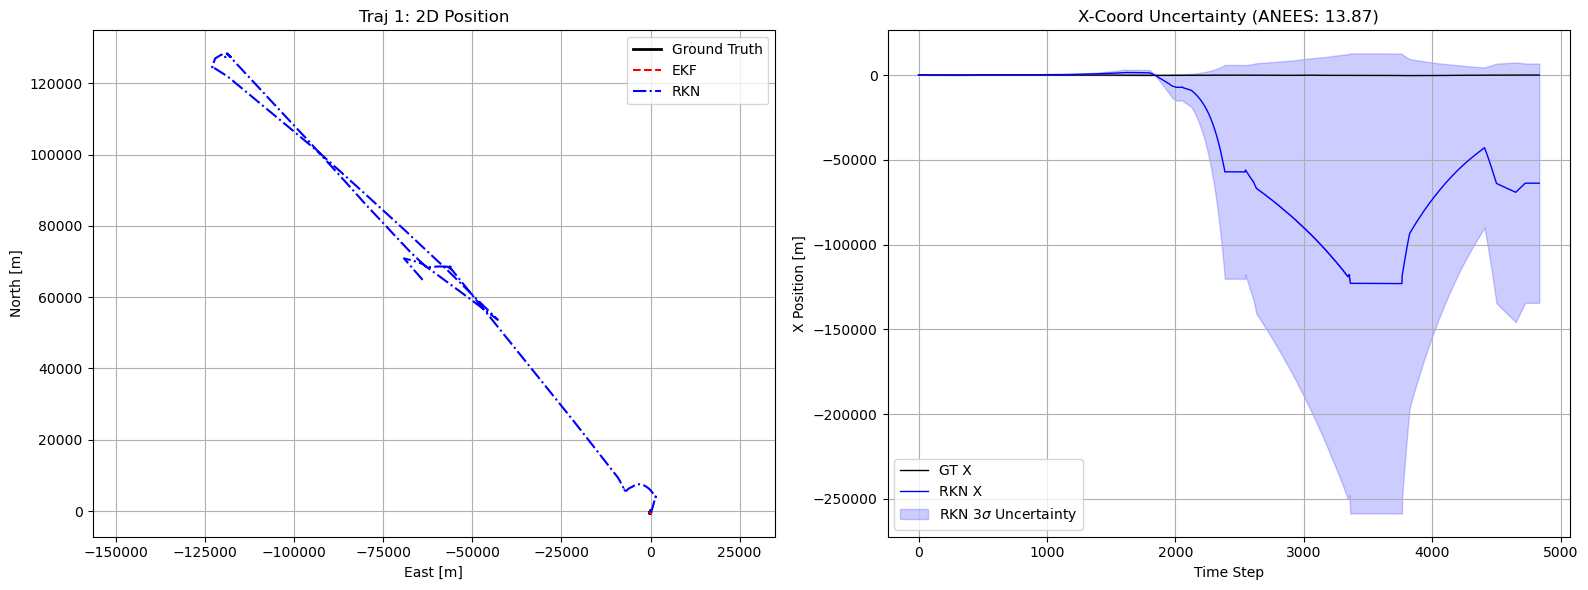

2            | 159.03     | 22.16      | 221.68     | 445.10     | 51.13     


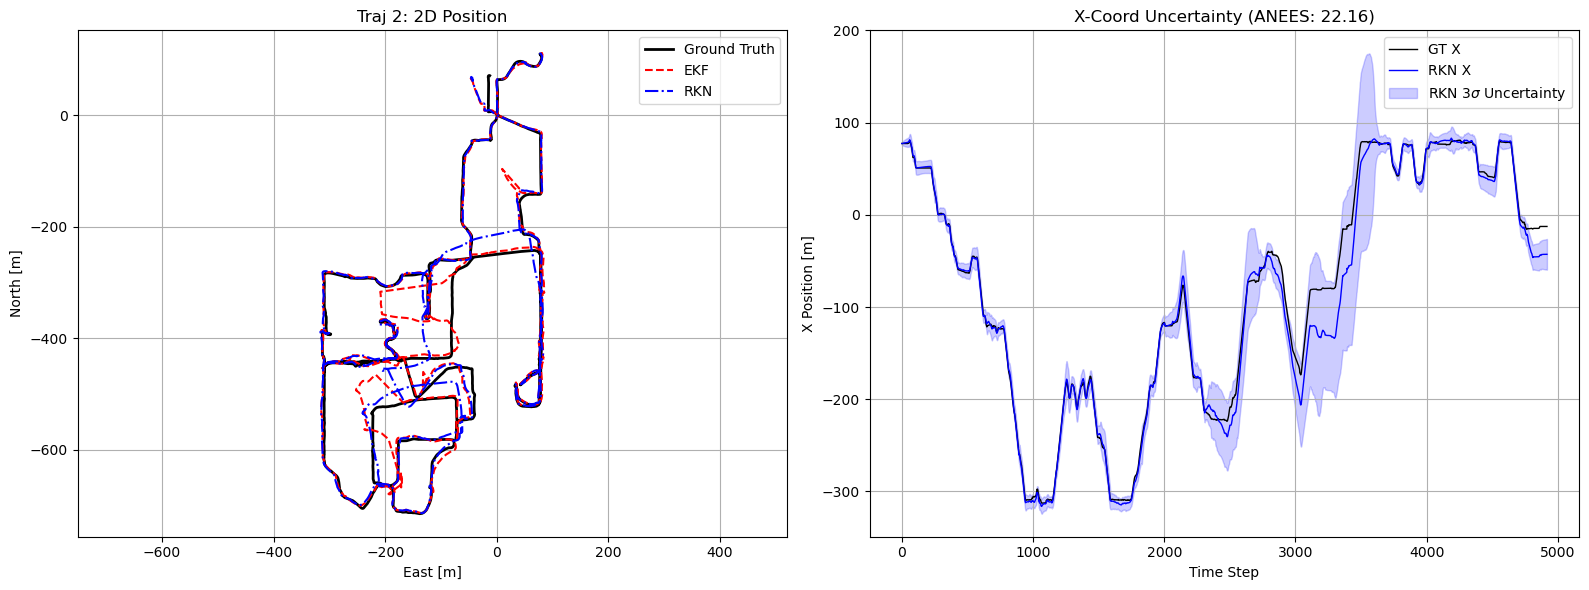

3            | 37.79      | 20.89      | 128.44     | 311.25     | 39.94     


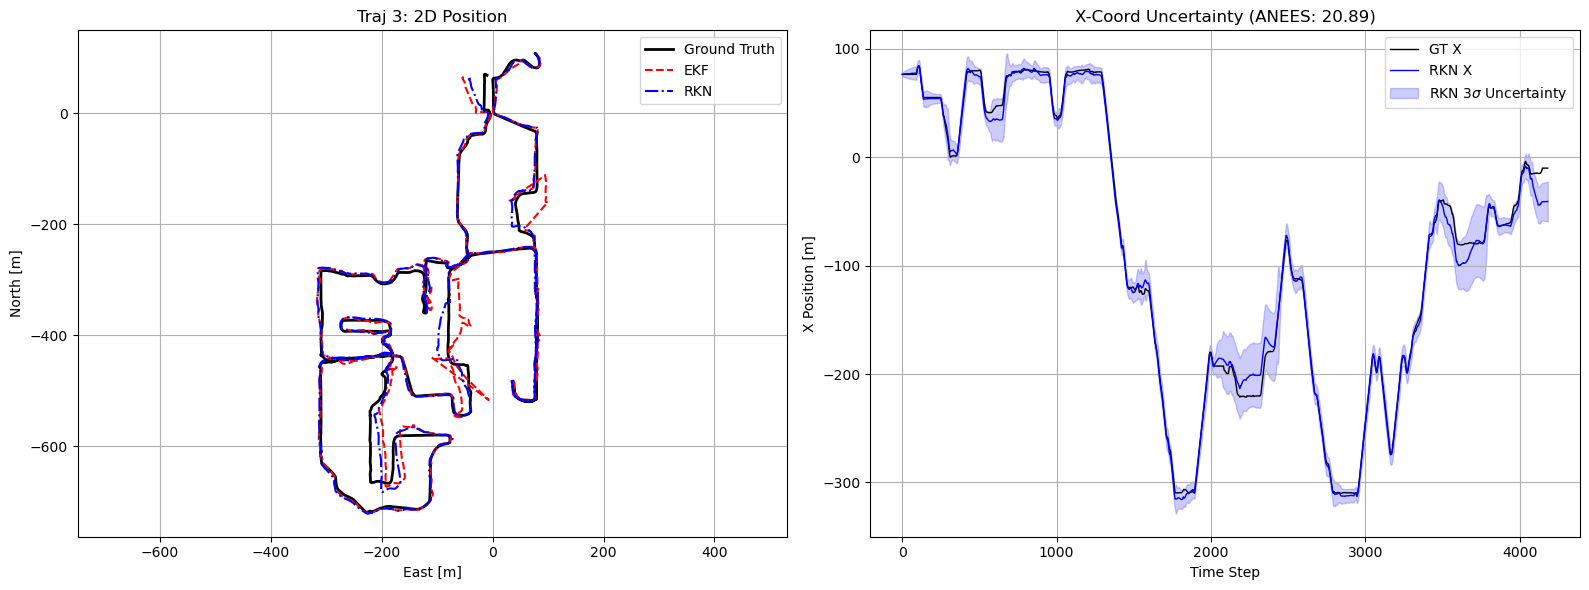


PRŮMĚRNÉ VÝSLEDKY (3 trajektorií)
Metoda     | MSE          | RMSE         | ANEES       
--------------------------------------------------------------------------------
RKN        | 1359686294.94 | 36873.92     | 18.97       
EKF        | 264.41       | 16.26        | 594.46      


In [11]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import Filters

# ==============================================================================
# 0. KONFIGURACE A MODEL
# ==============================================================================
DT_SEC = 1.0 

if hasattr(sys_model, 'dt'):
    sys_model.dt = DT_SEC
    print(f"INFO: Nastaveno sys_model.dt = {DT_SEC} s")

# Načtení RKN modelu
try:
    trained_model_rkn = state_rkn
    trained_model_rkn.eval()
    print("INFO: Používám Recursive KalmanNet (RKN).")
except NameError:
    raise NameError("Chyba: 'state_rkn' (RKN) neexistuje. Spusťte nejprve trénink.")

from Filters import NCLT
# Inicializace klasických filtrů
ukf_filter = NCLT.UnscentedKalmanFilterNCLT(sys_model) 
ekf_filter = NCLT.ExtendedKalmanFilterNCLT(sys_model)

# --- ROBUSTNÍ FUNKCE PRO ANEES ---
def calculate_anees(x_true, x_est, P_est):
    """
    Vypočítá ANEES. Očekává vstupy už se shodnou dimenzí.
    Používá pinv pro stabilitu.
    """
    T = x_true.shape[0]
    anees_list = []
    error = x_true - x_est 

    for t in range(T):
        e_t = error[t].unsqueeze(1) # [n, 1]
        P_t = P_est[t]              # [n, n]
        
        try:
            P_inv = torch.linalg.pinv(P_t, hermitian=True)
        except RuntimeError:
            P_inv = torch.eye(P_t.shape[0], device=P_t.device)
            
        nees = torch.mm(torch.mm(e_t.t(), P_inv), e_t).item()
        anees_list.append(nees)
        
    return np.mean(anees_list)

# ==============================================================================
# 1. EVALUACE A VIZUALIZACE
# ==============================================================================
results = {
    'GPS_Sensor': [],   
    'EKF_MSE': [],      'EKF_ANEES': [],
    'UKF_MSE': [],      'UKF_ANEES': [],
    'RKN_MSE': [],      'RKN_ANEES': []  # Přejmenováno z BKN
}

print(f"\nSpouštím detailní evaluaci na {len(test_data_raw)} trajektoriích...")

# HLAVIČKA DETAILNÍ TABULKY
print("\n" + "-"*95)
print(f"{'TRAJEKTORIE':<12} | {'RKN MSE':<10} | {'RKN ANEES':<10} | {'EKF MSE':<10} | {'EKF ANEES':<10} | {'GPS MSE':<10}")
print("-" * 95)

for i, traj in enumerate(test_data_raw):
    # --- PŘÍPRAVA DAT ---
    gt_raw = traj['ground_truth'].float().to(DEVICE)
    gps_filtered = traj['filtered_gps'].float().to(DEVICE)
    gps_filled = traj['gps'].float().to(DEVICE)
    imu_raw = traj['imu'].float().to(DEVICE)
    odo_raw = traj['filtered_wheel'].float().to(DEVICE)
    
    T_len = gt_raw.shape[0]
    
    # Input vector
    u_full = torch.stack((
        torch.nan_to_num(odo_raw[:, 0], nan=0.0),
        torch.nan_to_num(odo_raw[:, 1], nan=0.0),
        imu_raw[:, 2], 
        imu_raw[:, 3]
    ), dim=1).to(DEVICE)
    
    # Init State (bereme z GT)
    # x_true má dimenzi 3 (X, Y, Theta)
    x_true = gt_raw[:, :3] 
    
    # Init pro filtry (plná dimenze modelu)
    m = sys_model.state_dim
    x0_vec = torch.zeros(m).to(DEVICE)
    x0_vec[0] = x_true[0, 0]; x0_vec[1] = x_true[0, 1]
    if m >= 3 and x_true.shape[1] >= 3: x0_vec[4] = x_true[0, 2] 

    # --- A. BĚH RECURSIVE KALMANNET (RKN) ---
    batch_x0 = x0_vec.unsqueeze(0)
    trained_model_rkn.reset(batch_size=1, initial_state=batch_x0)
    
    rkn_x_list = [batch_x0]
    # První P0 pro t=0
    rkn_P_list = [sys_model.P0.unsqueeze(0)] 

    with torch.no_grad():
        for t in range(1, T_len):
            y_t = gps_filtered[t].unsqueeze(0)
            u_t = u_full[t].unsqueeze(0)
            
            # RKN vrací 3 hodnoty: x_filtered, P_filtered, dummy_reg
            x_est, P_est, _ = trained_model_rkn.step(y_t, u_t)
            
            rkn_x_list.append(x_est)
            # Ošetření dimenzí pro P, abychom z toho udělali tensor [1, m, m]
            if P_est.dim() < 3:
                P_est = P_est.unsqueeze(0)
            rkn_P_list.append(P_est)

    x_rkn = torch.cat(rkn_x_list, dim=0)    # [T, m]
    P_rkn = torch.cat(rkn_P_list, dim=0)    # [T, m, m]
    
    # Ochrana proti singulární matici: přidáme malý šum na diagonálu P
    P_rkn = P_rkn + torch.eye(m, device=DEVICE).unsqueeze(0) * 1e-6 

    # --- B. EKF & UKF ---
    def run_filter(flt):
        try:
            res = flt.process_sequence(gps_filtered, u_seq=u_full, Ex0=x0_vec, P0=sys_model.P0)
            return res['x_filtered'], res.get('P_filtered', torch.eye(m, device=DEVICE).repeat(T_len, 1, 1))
        except:
            return torch.zeros(T_len, m).to(DEVICE), torch.eye(m, device=DEVICE).repeat(T_len, 1, 1)

    x_ekf, P_ekf = run_filter(ekf_filter)
    x_ukf, P_ukf = run_filter(ukf_filter)

    # --- VYHODNOCENÍ (SLICING) ---
    eval_dim = x_true.shape[1] # 3 (X, Y, Theta)

    def evaluate_metrics(est_x, est_P):
        # MSE (poloha X, Y)
        mse = F.mse_loss(est_x[:, :2], x_true[:, :2]).item()
        # ANEES (Oříznuté na eval_dim)
        est_x_sliced = est_x[:, :eval_dim]
        est_P_sliced = est_P[:, :eval_dim, :eval_dim]
        anees = calculate_anees(x_true, est_x_sliced, est_P_sliced)
        return mse, anees

    mse_ekf, anees_ekf = evaluate_metrics(x_ekf, P_ekf)
    mse_ukf, anees_ukf = evaluate_metrics(x_ukf, P_ukf)
    mse_rkn, anees_rkn = evaluate_metrics(x_rkn, P_rkn)
    
    valid_mask = ~torch.isnan(gps_filtered[:, 0])
    mse_gps = F.mse_loss(gps_filtered[valid_mask], x_true[valid_mask, :2]).item() if valid_mask.sum() > 0 else np.nan

    # Ukládání
    results['GPS_Sensor'].append(mse_gps)
    results['EKF_MSE'].append(mse_ekf); results['EKF_ANEES'].append(anees_ekf)
    results['UKF_MSE'].append(mse_ukf); results['UKF_ANEES'].append(anees_ukf)
    results['RKN_MSE'].append(mse_rkn); results['RKN_ANEES'].append(anees_rkn)

    # --- VÝPIS ŘÁDKU TABULKY ---
    print(f"{i+1:<12} | {mse_rkn:<10.2f} | {anees_rkn:<10.2f} | {mse_ekf:<10.2f} | {anees_ekf:<10.2f} | {mse_gps:<10.2f}")

    # --- VIZUALIZACE ---
    gt_np = x_true.cpu().numpy()
    rkn_np = x_rkn.cpu().numpy()
    std_x_rkn = torch.sqrt(P_rkn[:, 0, 0]).cpu().numpy()
    t_axis = np.arange(T_len)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graf 1: 2D Trajektorie
    ax1.plot(gt_np[:, 0], gt_np[:, 1], 'k-', lw=2, label='Ground Truth')
    ax1.plot(x_ekf.cpu().numpy()[:, 0], x_ekf.cpu().numpy()[:, 1], 'r--', lw=1.5, label='EKF')
    ax1.plot(rkn_np[:, 0], rkn_np[:, 1], 'b-.', lw=1.5, label='RKN')
    ax1.set_title(f'Traj {i+1}: 2D Position')
    ax1.set_xlabel('East [m]'); ax1.set_ylabel('North [m]')
    ax1.legend(); ax1.grid(True); ax1.axis('equal')

    # Graf 2: Time Series X s Confidence Tube
    ax2.plot(t_axis, gt_np[:, 0], 'k-', lw=1, label='GT X')
    ax2.plot(t_axis, rkn_np[:, 0], 'b-', lw=1, label='RKN X')
    ax2.fill_between(t_axis, 
                     rkn_np[:, 0] - 3*std_x_rkn, 
                     rkn_np[:, 0] + 3*std_x_rkn, 
                     color='blue', alpha=0.2, label='RKN 3$\sigma$ Uncertainty')
    ax2.set_title(f'X-Coord Uncertainty (ANEES: {anees_rkn:.2f})')
    ax2.set_xlabel('Time Step'); ax2.set_ylabel('X Position [m]')
    ax2.legend(); ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 2. FINÁLNÍ SOUHRN
# ==============================================================================
print("\n" + "="*80)
print(f"PRŮMĚRNÉ VÝSLEDKY ({len(test_data_raw)} trajektorií)")
print("="*80)
print(f"{'Metoda':<10} | {'MSE':<12} | {'RMSE':<12} | {'ANEES':<12}")
print("-" * 80)
print(f"{'RKN':<10} | {np.nanmean(results['RKN_MSE']):<12.2f} | {np.sqrt(np.nanmean(results['RKN_MSE'])):<12.2f} | {np.nanmean(results['RKN_ANEES']):<12.2f}")
print(f"{'EKF':<10} | {np.nanmean(results['EKF_MSE']):<12.2f} | {np.sqrt(np.nanmean(results['EKF_MSE'])):<12.2f} | {np.nanmean(results['EKF_ANEES']):<12.2f}")
print("="*80)